In [94]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
 
from discretize import TensorMesh
from simpeg.potential_fields import magnetics
from simpeg import maps, data

In [95]:
B0_inclination  =  70.0  
B0_declination  =  20.0  
B0_amplitude    = 50000000

In [96]:
x_survey = np.linspace(-10, 10, 81)   #81 stations
y_survey = np.zeros_like(x_survey)
z_survey = np.ones_like(x_survey) * 0.1  #10 cm above surface (like drone)

receiver_locations = np.c_[x_survey, y_survey, z_survey]

In [97]:
rx = magnetics.receivers.Point(
    receiver_locations, components="tmi"
)

src = magnetics.sources.UniformBackgroundField(
    receiver_list=[rx],
    amplitude=B0_amplitude,
    inclination=B0_inclination,
    declination=B0_declination,
)
 
survey = magnetics.survey.Survey(src)

In [98]:
hx = [(0.5, 10, -1.3),     
      (0.25, 80),          
      (0.5, 10,  1.3)]    

hy = [(20., 1)]            

hz = [(0.25, 20),          
      (0.5,  10, 1.3)]     

mesh = TensorMesh([hx, hy, hz], origin="CN0")

print(f"Mesh: {mesh.nC} cells  ({mesh.shape_cells})")        



Mesh: 3000 cells  ((100, 1, 30))


In [99]:
# Make model

chi_background = 1e-4   
chi_uxo        = 0.3    

# Uxo specifications
uxo_x_center = 0.0    
uxo_z_center = -1.5   
uxo_half_width = 0.3  
uxo_half_depth = 0.2 
 
cc = mesh.cell_centers  
 
model = np.full(mesh.nC, chi_background)
 
uxo_mask = (
    (cc[:, 0] >= uxo_x_center - uxo_half_width) &
    (cc[:, 0] <= uxo_x_center + uxo_half_width) &
    (cc[:, 1] >= uxo_z_center - uxo_half_depth) &
    (cc[:, 1] <= uxo_z_center + uxo_half_depth)
)
model[uxo_mask] = chi_uxo

print(f"UXO cells: {uxo_mask.sum()} "
      f"(at x={uxo_x_center} m, z={uxo_z_center} m)")

UXO cells: 0 (at x=0.0 m, z=-1.5 m)


In [100]:
chi_map = maps.IdentityMap(nP=mesh.nC)
 
sim = magnetics.simulation.Simulation3DIntegral(
    mesh,
    survey=survey,
    chiMap=chi_map,
    ind_active=None,   # all cells active (no topography masking)
    store_sensitivities="forward_only",
)

In [101]:
tmi_predicted = sim.dpred(model)   # nT
 
print(f"\nTMI anomaly range: {tmi_predicted.min():.1f} to "
      f"{tmi_predicted.max():.1f} nT")
 
# Gaussian noise
rng   = np.random.default_rng(42)
noise = rng.normal(0, 2.0, size=tmi_predicted.shape)
tmi_noisy = tmi_predicted + noise


TMI anomaly range: 988.8 to 1021.6 nT


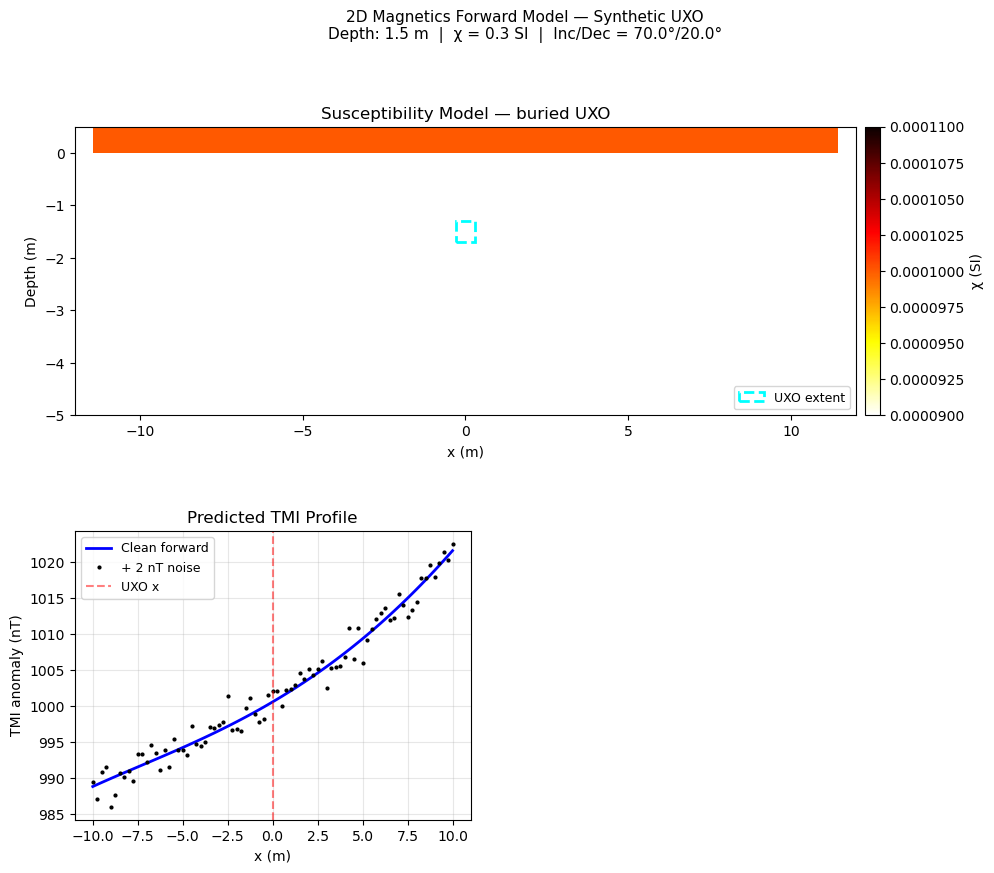


Plot saved to uxo_magnetics_forward.png


In [102]:
from matplotlib.patches import Rectangle
 
fig = plt.figure(figsize=(12, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
 
# susceptibility 
ax0 = fig.add_subplot(gs[0, :])
 
# Reshape for a single y slice
model_3d   = model.reshape(mesh.shape_cells, order="F")  
model_slice = model_3d[:, 0, :]                           
 
xc = mesh.cell_centers_x
zc = mesh.cell_centers_z
 
x_mask = (xc >= -12) & (xc <= 12)
z_mask = (zc >= -5)  & (zc <=  0.5)
 
im = ax0.pcolormesh(
    xc[x_mask],
    zc[z_mask],
    model_slice[np.ix_(x_mask, z_mask)].T,
    cmap="hot_r",
    shading="auto",
)
plt.colorbar(im, ax=ax0, label="χ (SI)", pad=0.01)
 
# UXO 
rect = Rectangle(
    (uxo_x_center - uxo_half_width, uxo_z_center - uxo_half_depth),
    2 * uxo_half_width, 2 * uxo_half_depth,
    linewidth=2, edgecolor="cyan", facecolor="none",
    linestyle="--", label="UXO extent",
)
ax0.add_patch(rect)
ax0.set_xlim(-12, 12)
ax0.set_ylim(-5, 0.5)
ax0.set_xlabel("x (m)")
ax0.set_ylabel("Depth (m)")
ax0.set_title("Susceptibility Model — buried UXO")
ax0.legend(loc="lower right", fontsize=9)


# Tmi
ax1 = fig.add_subplot(gs[1, 0])
ax1.plot(x_survey, tmi_predicted, "b-", lw=2, label="Clean forward")
ax1.plot(x_survey, tmi_noisy,     "k.", ms=4, label="+ 2 nT noise")
ax1.axvline(uxo_x_center, color="r", linestyle="--", alpha=0.5, label="UXO x")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("TMI anomaly (nT)")
ax1.set_title("Predicted TMI Profile")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

 
fig.suptitle(
    f"2D Magnetics Forward Model — Synthetic UXO\n"
    f"Depth: {abs(uxo_z_center):.1f} m  |  χ = {chi_uxo} SI  |  "
    f"Inc/Dec = {B0_inclination}°/{B0_declination}°",
    fontsize=11, y=1.01,
)
 
plt.show()
print("\nPlot saved to uxo_magnetics_forward.png")